## Sentiment analysis
- Sentiment analysis refers to analyzing an opinion or feelings about something using data such as text
- Sources of sentiment einclude social media, opinion polls, surveys, etc

## Scenario
Suppose there is a collection of tweets about six US airlines, the task is to predict whether a tweet contains positive, negative, or neutral sentiment about an airline. 

This is a <b> supervised learning</b> task where given a text string, we have to categorize the text string into predefined categories.

## How to solve it
- follow a the standard machine learning pipeline:
  -  import the required libraries and the dataset.
  -  do exploratory data analysis to check any trends in the dataset. 
  - perform text preprocessing to convert textual data to numeric data that can be used by a machine learning algorithm. 
  - use machine learning algorithms to train and test the sentiment analysis model.

In [119]:
#pip install nltk

## Import the libraries

In [1]:
import numpy as np 
import pandas as pd 
import re
import nltk 
import matplotlib.pyplot as plt

## Use pandas to import the dataset

In [2]:
tweetsFile = 'Tweets.csv'
airlineData = pd.read_csv(tweetsFile)

## Check the data

In [3]:
airlineData.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
airlineData['text'].head(10)

0                  @VirginAmerica What @dhepburn said.
1    @VirginAmerica plus you've added commercials t...
2    @VirginAmerica I didn't today... Must mean I n...
3    @VirginAmerica it's really aggressive to blast...
4    @VirginAmerica and it's a really big bad thing...
5    @VirginAmerica seriously would pay $30 a fligh...
6    @VirginAmerica yes, nearly every time I fly VX...
7    @VirginAmerica Really missed a prime opportuni...
8      @virginamerica Well, I didn't…but NOW I DO! :-D
9    @VirginAmerica it was amazing, and arrived an ...
Name: text, dtype: object

In [5]:
airlineData.airline.unique()

array(['Virgin America', 'United', 'Southwest', 'Delta', 'US Airways',
       'American'], dtype=object)

## A bif of Data Analysis
- explore the dataset a little to see if we can find any trends. 
- Let's do a customised plot to have a better view of the data

In [8]:
# figure settings
plot_size = plt.rcParams["figure.figsize"] 
print(plot_size[0]) 
print(plot_size[1])

plot_size[0] = 10
plot_size[1] = 8
plt.rcParams["figure.figsize"] = plot_size

6.0
4.0


## Number of tweets for each airline
-  We will plot a pie chart for that

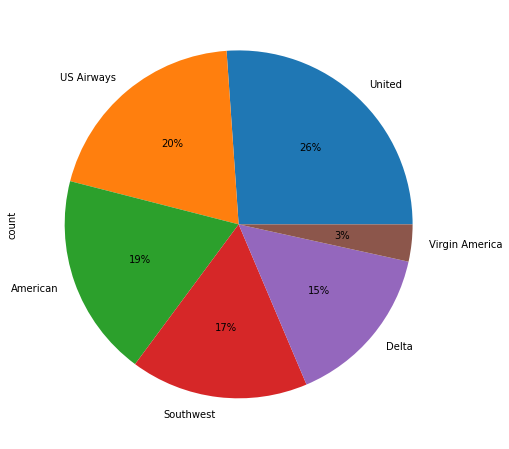

In [9]:
airlineData.airline.value_counts().plot(kind='pie', autopct='%1.0f%%');
# autopct='%1.0f%%' - to display the %


## Reflections
- United Airline has the highest number of tweets i.e. 26%, followed by US Airways (20%).
- Virgin America has fewest tweets

## Distribution of sentiments across the tweets

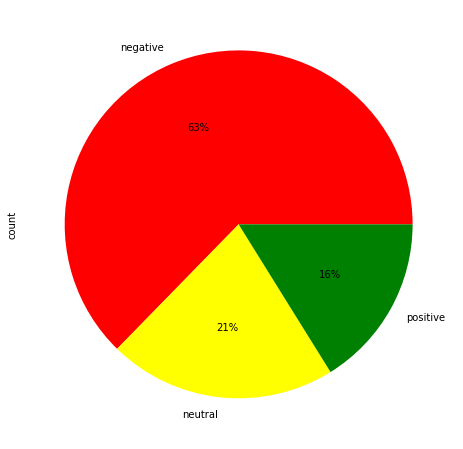

In [10]:
airlineData.airline_sentiment.value_counts().plot(kind='pie', autopct='%1.0f%%', colors=["red", "yellow", "green"]);

## Reflections
-  majority of the tweets are negative (63%)
- Neutral sentiments are more than positive ones

## Distribution of sentiment for each airline

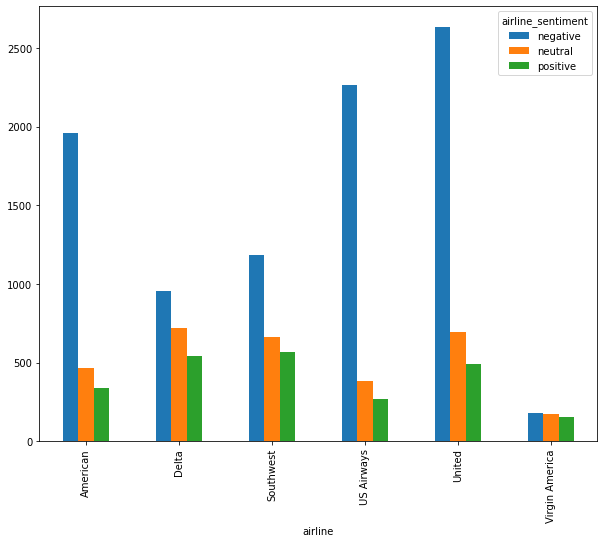

In [11]:
airline_sentiment = airlineData.groupby(['airline', 'airline_sentiment']).airline_sentiment.count().unstack()
airline_sentiment.plot(kind='bar');

In [47]:
airline_sentiment.head()

airline_sentiment,negative,neutral,positive
airline,,,
American,1960,463,336
Delta,955,723,544
Southwest,1186,664,570
US Airways,2263,381,269
United,2633,697,492


## Reflection
-  for almost all the airlines, the majority of the tweets are negative, followed by neutral and positive tweets. 
- Virgin America is probably the only airline where the ratio of the three sentiments is fairly similar.

## Data Cleaning

- Cleaning to remove/tidy up slung words, punctuation marks, etc
- cleaning necessary before training a machine learning model. 
- However, first, divide  dataset into <b>feature</b> and <b>label</b> sets. <br>

<b>Feature sets:</b> <br>
-  consist of tweets only. This is in the 11th column. <br>

<b>Label set:</b><br>
 - consists of the sentiment of the tweet that we have to predict. This is in the second column. <br>



## Creating feature and label sets

In [12]:
features = airlineData.iloc[:, 10].values
labels = airlineData.iloc[:, 1].values

In [24]:
#airlineData.head()


## We preprocess the data in order to clean it

In [13]:
processed_features = []

for sentence in range(0, len(features)):
    # Remove all the special characters
    processed_feature = re.sub(r'\W', ' ', str(features[sentence]))

    # remove all single characters
    processed_feature= re.sub(r'\s+[a-zA-Z]\s+', ' ', processed_feature)

    # Remove single characters from the start
    processed_feature = re.sub(r'\^[a-zA-Z]\s+', ' ', processed_feature) 

    # Substitute multiple spaces with single space
    processed_feature = re.sub(r'\s+', ' ', processed_feature, flags=re.I)

    # Removing prefixed 'b'
    processed_feature = re.sub(r'^b\s+', '', processed_feature)

    # Converting to Lowercase
    processed_feature = processed_feature.lower()

    processed_features.append(processed_feature)

In [14]:
processed_features[:10]

[' virginamerica what dhepburn said ',
 ' virginamerica plus you ve added commercials to the experience tacky ',
 ' virginamerica didn today must mean need to take another trip ',
 ' virginamerica it really aggressive to blast obnoxious entertainment in your guests faces amp they have little recourse',
 ' virginamerica and it a really big bad thing about it',
 ' virginamerica seriously would pay 30 flight for seats that didn have this playing it really the only bad thing about flying va',
 ' virginamerica yes nearly every time fly vx this ear worm won go away ',
 ' virginamerica really missed prime opportunity for men without hats parody there https co mwpg7grezp',
 ' virginamerica well didn but now do d',
 ' virginamerica it was amazing and arrived an hour early you re too good to me ']

## Representing text as numbers
### Bag of words
Example, if we have the text: <br>
- Doc1 = "I like to play football"
- Doc2 = "It is a good game"
- Doc3 = "I prefer football over rugby"

1. First create a vocabulary of all unique words<br>
<b>Vocab</b>` = [I, like, to, play, football, it, is, a, good, game, prefer, over, rugby]` <br>
2. The next step is to convert each document into a feature vector using the vocabulary. <br>

The length of each feature vector is equal to the length of the vocabulary. The frequency of the word in the document will replace the actual word in the vocabulary. If a word in the vocabulary is not found in the corresponding document, the document feature vector will have zero in that place.<br>
<b>Example based on above documents</b>:
Doc1's Feature vector will be:<br> `[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]`

### TF-IDF (Term frequency and Inverse Document frequency)
With the bag of words approach, each word has the same weight.<br>
The idea behind the TF-IDF approach is that the <b>words that occur less</b> in all the documents and <b>more in individual document</b> contribute more towards classification.

<b> TF  = (Frequency of a word in the document)/(Total words in the document) </b>

<b>IDF = Log((Total number of docs)/(Number of docs containing the word)) </b>

<em> We go for TF-IDF</em>

In [15]:
import nltk
nltk.download('stopwords') 
# A stop word -  commonly used word (e.g., “the”, “a”, “an”, “in”) that aren't consider useful in a corpus 

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/johnkanyaru/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer (max_features=2500, min_df=7, max_df=0.8, stop_words=stopwords.words('english'))
processed_features = vectorizer.fit_transform(processed_features).toarray()

## What have we just done above?
We define that <b>max_features</b> should be 2500. This  means that we only use the 2500 most frequently occurring words to create a bag of words feature vector. Words that occur less frequently are not very useful for classification.

Also, <b>max_df</b> specifies that only use those words that occur in a maximum of 80% of the documents. Words that occur in all documents are too common and are not very useful for classification. Similarly, <b>min-df</b> is set to 7 which shows that include words that occur in at least 7 documents.

## Divide Data into Training and Test Sets
What we did above -  we converted the data into numeric form. <br>
Before we train our algorithm, we need to divide our data into training and testing sets. 

- What is the training set for?
- What is the test set for?

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(processed_features, labels, test_size=0.2, random_state=0)

## Reflections
- what is X_train? Check it's shape
- What is X_test? Check it's shape
- What are y_train and y_test? Check their shapes too
- What does test_size do?
- what does random_state parameter do?

## Training the model
Choice of algorithm - we use the Random Forest because it  performs quite well on non-normalised data.
The <b>sklearn.ensemble</b> module contains the `RandomForestClassifier`; we will instantiate a model from it.

## How the RandomForestClassifier works
- builds multiple decision trees and merges them together to get a more accurate and stable prediction.
- The "forest" it builds, is an ensemble of decision trees,  trained with the “bagging” method. 
- The general idea of the bagging method is that a combination of learning models increases the overall result. <br>

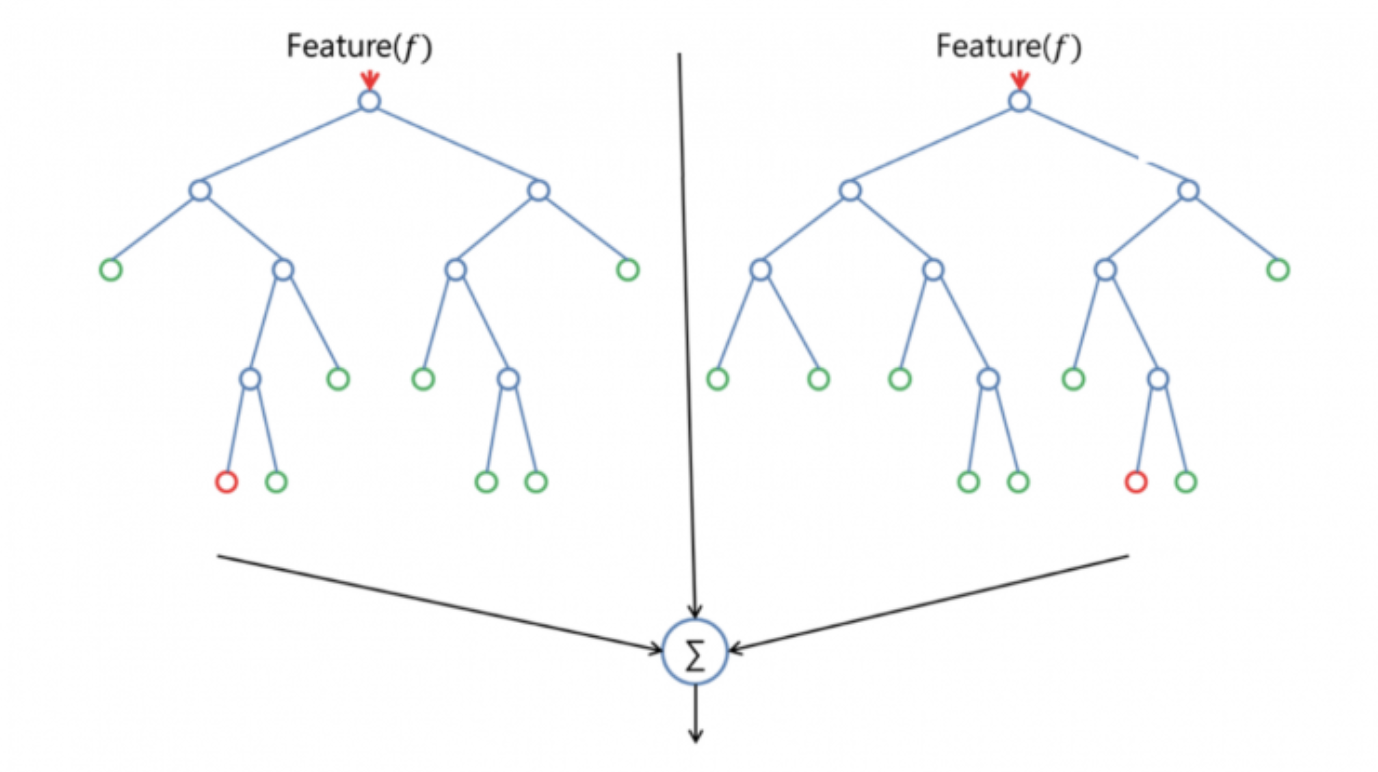
 

## A bit more about random forests and how they relate to decision trees
- Tree terminology
  - internal node -  a 'test' on an attribute (e.g. whether a negative, positive)
  - branch - outcome of the test
  - leaf node -  a class label (final decision after checking all attributes) <br>

<b>Random forest</b> -  consists of a large number of individual decision trees that operate as an ensemble. Each individual tree in the random forest outputs a class prediction and the class with the most votes (or an average) becomes our model’s prediction. <br>
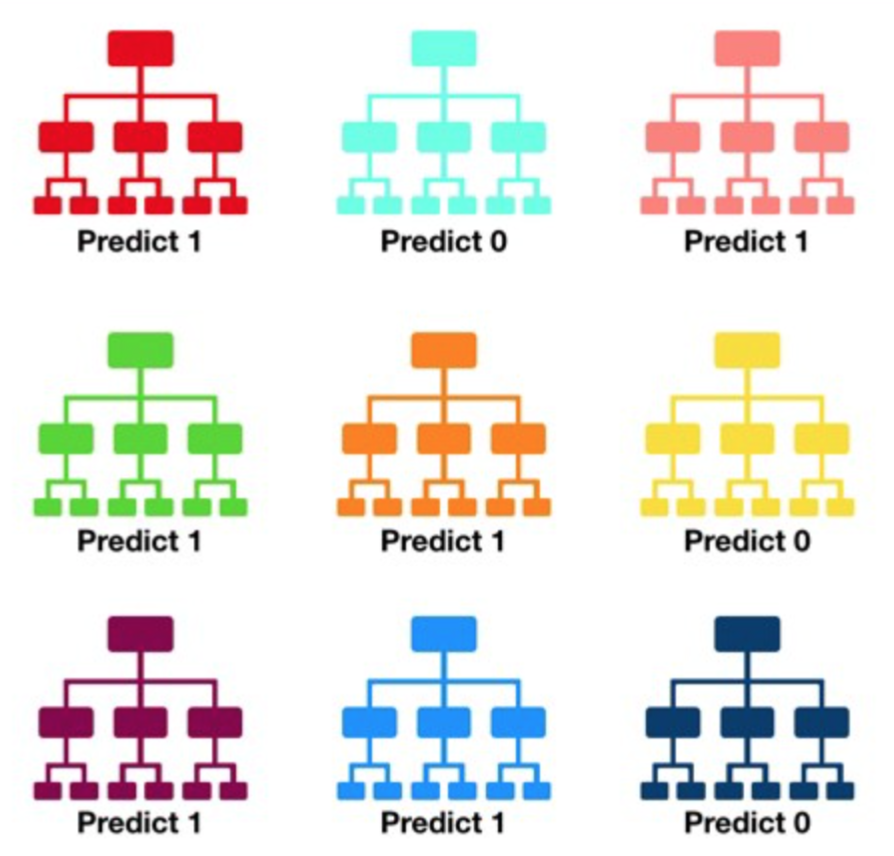

Above - There are 6 predictions of 1, and 3 predictions of 0. So, 1 wins.

In [18]:
from sklearn.ensemble import RandomForestClassifier

text_classifier = RandomForestClassifier(n_estimators=201)


In [19]:
text_classifier.fit(X_train, y_train)
#n_estimators - the number of trees in the forest - how many trees to build before taking an average or a vote

RandomForestClassifier(n_estimators=201)

## Making predictions
We use our trained model to make preditions. We also evaluate it's performance on the test dataset

In [20]:
predictions = text_classifier.predict(X_test)

In [21]:
print(y_test[1], predictions[1])

negative negative


## Reflections
- What does predictions comprise of?

## Evaluate the model performance
Techniques include:
-  metrics such as a confusion matrix, F1 measure, accuracy, recall, etc


In [53]:
from sklearn.metrics import confusion_matrix, accuracy_score

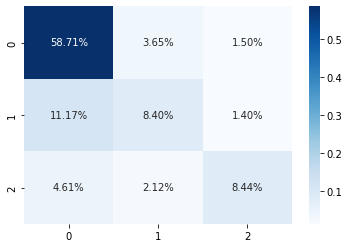

In [55]:
cf_matrix = confusion_matrix(y_test,predictions)
import seaborn as sns
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues');

## What really is a Confusion Matrix?
- an N x N matrix used for evaluating the performance of a classification model
- N is the number of target classes. 
- The matrix compares the actual target values with those predicted by the model. 
- It provides an overall view of how well our classification model is performing and what kinds of errors it is making.

In [30]:
print(accuracy_score(y_test, predictions))

0.7602459016393442
